# 🧠 Convolutional Variational Autoencoder (CVAE)
### Computer Vision Course — Demo Notebook

**Authors:** Dr. Dimitris Mousadakos, Dr. Aygul Zagidullina  
**Dataset:** MNIST handwritten digits  
**Framework:** TensorFlow / Keras  
**Runtime:** Google Colab (GPU recommended ✅)

---

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

1. Explain the key difference between a **standard autoencoder** and a **Variational Autoencoder (VAE)**
2. Understand the **reparameterization trick** and why it is necessary for training
3. Derive and implement the **Evidence Lower BOund (ELBO)** loss function
4. Build a **Convolutional VAE** using TensorFlow/Keras from scratch
5. Visualise the **latent space** and generate new images by sampling from it

---

## 📚 Background: From Autoencoders to Variational Autoencoders

### Standard Autoencoder (AE)

A classic autoencoder compresses an input $x$ into a **fixed latent vector** $z$ (the bottleneck), then reconstructs $\hat{x}$ from it:

$$x \xrightarrow{\text{Encoder}} z \xrightarrow{\text{Decoder}} \hat{x}$$

The latent space is **deterministic** — each input always maps to the same point. This makes generation difficult: we cannot easily sample new, valid points from a deterministic space.

### Variational Autoencoder (VAE)

A VAE, introduced by [Kingma & Welling (2013)](https://arxiv.org/abs/1312.6114) and [Rezende et al. (2014)](https://arxiv.org/abs/1401.4082), treats the latent space **probabilistically**:

- The **encoder** outputs parameters $\mu$ and $\sigma$ of a Gaussian distribution $q(z|x)$
- We **sample** $z \sim q(z|x)$ stochastically
- The **decoder** reconstructs the image from $z$

This forces the latent space to be **continuous and structured**, enabling meaningful generation.

$$x \xrightarrow{\text{Encoder}} (\mu, \sigma) \xrightarrow{\text{Sample}} z \xrightarrow{\text{Decoder}} \hat{x}$$

| Feature | Standard AE | VAE |
|---|---|---|
| Latent representation | Single point | Probability distribution |
| Can generate new samples? | ❌ (no structure guaranteed) | ✅ (sample from prior $p(z)$) |
| Latent space continuity | Not guaranteed | Enforced by KL regularisation |
| Training objective | Reconstruction loss only | ELBO = Reconstruction + KL |

**Example of the VAE latent space (MNIST):**

![CVAE latent space](https://github.com/tensorflow/docs/blob/master/site/en/tutorials/generative/images/cvae_latent_space.jpg?raw=1)

*Each colour represents a digit class. Notice how classes form smooth, overlapping clusters — not isolated islands. This is the effect of KL regularisation.*


---
## 🔧 Step 1: Install Dependencies

We need three packages beyond the standard Colab environment:

- **`tensorflow-probability`**: provides the Normal distribution and its quantile function, used when visualising the latent space grid
- **`imageio`**: compiles per-epoch PNG images into an animated GIF so we can watch training progress
- **`tensorflow-docs`**: a utility from the TensorFlow team that embeds GIFs natively in Colab output cells


In [ ]:
!pip install -q tensorflow-probability imageio git+https://github.com/tensorflow/docs
print("✅ All dependencies installed successfully.")


  Preparing metadata (setup.py) ... done
✅ All dependencies installed successfully.


---
## 📦 Step 2: Import Libraries

| Library | Purpose |
|---|---|
| `tensorflow` + `keras` | Build and train the neural network |
| `tensorflow_probability` | Normal distribution quantile for latent visualisation |
| `numpy` | Numerical operations, array manipulation |
| `matplotlib` | Plotting images and learning curves |
| `PIL` | Reading saved PNG files |
| `imageio` / `glob` | Assembling the training GIF |
| `time` | Timing each training epoch |


In [ ]:
from IPython import display

import glob
import imageio
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
import tensorflow_probability as tfp
import time

# Confirm GPU availability — essential for reasonable training speed
print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU detected: {gpus[0].name}")
else:
    print("⚠️  No GPU found. Enable it via: Runtime → Change runtime type → T4 GPU")


TensorFlow version: 2.20.0
✅ GPU detected: /physical_device:GPU:0


---
## 📊 Step 3: Load and Preprocess MNIST

### About MNIST
MNIST contains **70,000 grayscale images** of handwritten digits (0–9):
- **Training set:** 60,000 images
- **Test set:** 10,000 images
- **Image size:** 28×28 pixels, original values in [0, 255]

### Preprocessing pipeline

We apply three steps:

1. **Reshape**: Add a channel dimension → shape `(N, 28, 28, 1)` required by `Conv2D`
2. **Normalise**: Divide by 255 → pixel values in [0, 1]
3. **Binarise**: Threshold at 0.5 → pixels become exactly 0.0 or 1.0

> **Why binarise?** We model each pixel as a **Bernoulli random variable** (on/off).  
> The correct likelihood for Bernoulli data is **binary cross-entropy**, which is what our loss function uses.  
> This is a deliberate modelling choice — it simplifies $\log p(x|z)$ while still producing good results on MNIST.


In [ ]:
# Load raw MNIST — labels are discarded (VAE is an unsupervised model)
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

print(f"Raw train shape : {train_images.shape}  |  dtype: {train_images.dtype}")
print(f"Raw test  shape : {test_images.shape}   |  dtype: {test_images.dtype}")
print(f"Pixel value range: [{train_images.min()}, {train_images.max()}]")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Raw train shape : (60000, 28, 28)  |  dtype: uint8
Raw test  shape : (10000, 28, 28)   |  dtype: uint8
Pixel value range: [0, 255]


In [ ]:
def preprocess_images(images):
    """
    Preprocess MNIST images for the CVAE:
      1. Reshape to (N, 28, 28, 1) — adds channel dimension for Conv2D
      2. Normalise to [0, 1] by dividing by 255
      3. Binarise: pixels > 0.5 → 1.0 (on), else → 0.0 (off)
         This models each pixel as a Bernoulli(p) random variable.
    """
    images = images.reshape((images.shape[0], 28, 28, 1)) / 255.0
    return np.where(images > 0.5, 1.0, 0.0).astype('float32')

train_images = preprocess_images(train_images)
test_images  = preprocess_images(test_images)

print(f"Processed train shape : {train_images.shape}")
print(f"Processed test  shape : {test_images.shape}")
print(f"Unique pixel values   : {np.unique(train_images)}  ← binary confirmed")


Processed train shape : (60000, 28, 28, 1)
Processed test  shape : (10000, 28, 28, 1)
Unique pixel values   : [0. 1.]  ← binary confirmed


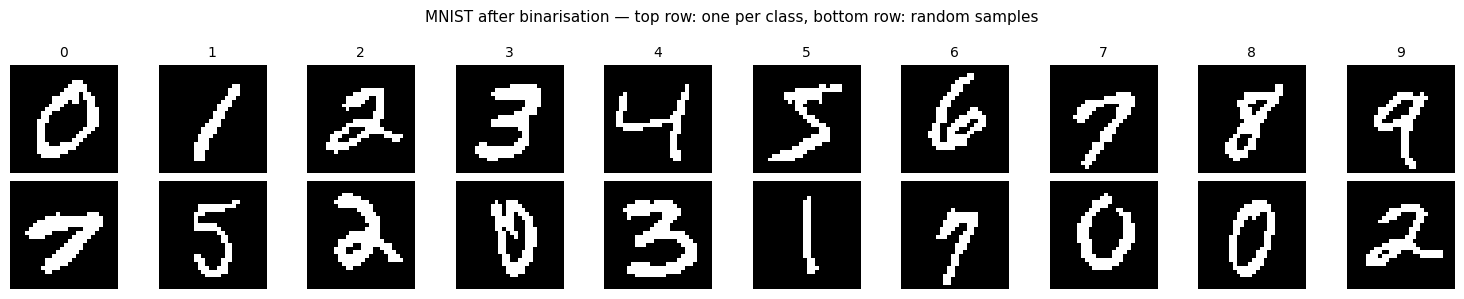

In [ ]:
# Visualise samples after binarisation
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
fig.suptitle('MNIST after binarisation — top row: one per class, bottom row: random samples', fontsize=11)

for digit in range(10):
    idx = np.where(train_labels == digit)[0][0]
    axes[0, digit].imshow(train_images[idx, :, :, 0], cmap='gray')
    axes[0, digit].set_title(str(digit), fontsize=10)
    axes[0, digit].axis('off')

rng_idx = np.random.choice(len(train_images), 10, replace=False)
for col, idx in enumerate(rng_idx):
    axes[1, col].imshow(train_images[idx, :, :, 0], cmap='gray')
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('One per class', fontsize=8)
axes[1, 0].set_ylabel('Random', fontsize=8)
plt.tight_layout()
plt.show()


---
## 🔄 Step 4: Build the `tf.data` Pipeline

Using `tf.data` instead of plain NumPy arrays gives us:

- **Shuffling** at each epoch: prevents the model from memorising the order of training examples
- **Batching**: gradients are averaged over `BATCH_SIZE=32` images, giving more stable updates than per-sample SGD
- **Prefetching** (`AUTOTUNE`): the CPU prepares the next batch while the GPU processes the current one, eliminating idle time

> **Batch size = 32:** A classic choice balancing gradient quality and GPU memory.  
> Larger batches → smoother gradients but higher memory use and sometimes worse generalisation.


In [ ]:
TRAIN_SIZE = 60_000
TEST_SIZE  = 10_000
BATCH_SIZE = 32

train_dataset = (
    tf.data.Dataset.from_tensor_slices(train_images)
    .shuffle(TRAIN_SIZE)           # Shuffle the full dataset each epoch
    .batch(BATCH_SIZE)             # Group into mini-batches of 32
    .prefetch(tf.data.AUTOTUNE)    # Overlap data loading with GPU compute
)

test_dataset = (
    tf.data.Dataset.from_tensor_slices(test_images)
    .shuffle(TEST_SIZE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print(f"Training batches per epoch : {TRAIN_SIZE // BATCH_SIZE:,}")
print(f"Test    batches per epoch  : {TEST_SIZE  // BATCH_SIZE:,}")

for batch in train_dataset.take(1):
    print(f"\nSample batch  shape : {batch.shape}")
    print(f"Min / Max values    : {batch.numpy().min():.1f} / {batch.numpy().max():.1f}")


Training batches per epoch : 1,875
Test    batches per epoch  : 312

Sample batch  shape : (32, 28, 28, 1)
Min / Max values    : 0.0 / 1.0


---
## 🏗️ Step 5: Define the CVAE Architecture

### 5.1 Architecture Overview

```
ENCODER                                   DECODER
x (28×28×1)                               z (latent_dim,)
    │                                           │
Conv2D(32, 3×3, stride=2) → 13×13×32     Dense(7×7×32)
Conv2D(64, 3×3, stride=2) →  6×6×64      Reshape(7×7×32)
Flatten                                   ConvTranspose(64, 3×3, stride=2) → 14×14×64
Dense(2 × latent_dim)                     ConvTranspose(32, 3×3, stride=2) → 28×28×32
    │                                     ConvTranspose( 1, 3×3, stride=1) → 28×28×1
Split → μ, log σ²                              │
                                          x̂ (28×28×1)  ← logits (no activation)
```

### 5.2 The Reparameterization Trick (in detail)

Sampling $z \sim \mathcal{N}(\mu, \sigma^2)$ is **non-differentiable** —  
backpropagation cannot flow through a stochastic node.

**Solution:** Rewrite the sample as a deterministic function of the parameters plus independent noise:

$$z = \mu + \sigma \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

Now $\mu$ and $\sigma$ are deterministic outputs of the encoder; gradients flow freely through them.  
$\epsilon$ is sampled independently — it carries all the randomness but has no trainable parameters.

```
Without trick:   x → Encoder → (μ, σ) → SAMPLE (✗ no gradient) → z → Decoder
With trick:      x → Encoder → (μ, σ) ─────────────────────────→ z → Decoder
                                              ↑
                                         ε ~ N(0,1)  [independent]
```

### 5.3 Why output log-variance instead of variance?

- Variance must be **positive** ($\sigma^2 > 0$). If the network directly outputs $\sigma^2$, it could predict negative values.
- $\log \sigma^2$ is **unconstrained** (any real number), which is easier for the network to optimise.
- We recover $\sigma = \exp(\frac{1}{2} \log \sigma^2)$, which is always positive.

### 5.4 Why no Batch Normalisation?

Batch Norm introduces extra stochasticity (from batch statistics estimation) on top of the sampling noise already present.  
This compounds instability. VAEs are typically trained without it.


In [ ]:
class CVAE(tf.keras.Model):
    """Convolutional Variational Autoencoder (CVAE) on 28×28 grayscale images.

    Encoder: Conv2D(32) → Conv2D(64) → Flatten → Dense(2*latent_dim)
             Outputs μ and log σ² of the approximate posterior q(z|x)

    Decoder: Dense(7*7*32) → Reshape → ConvTranspose(64) → ConvTranspose(32) → ConvTranspose(1)
             Reconstructs the image from a latent sample z
    """

    def __init__(self, latent_dim):
        super(CVAE, self).__init__()
        self.latent_dim = latent_dim

        # ── ENCODER ──────────────────────────────────────────────────────────
        # Maps x (28×28×1) → (μ, log σ²) each of shape (latent_dim,)
        #
        # Spatial progression (stride=2 halves each spatial dim):
        #   28×28 → 13×13 (after Conv 1) → 6×6 (after Conv 2)
        # Dense output: 2*latent_dim values, split into μ and log σ²
        self.encoder = tf.keras.Sequential([
            tf.keras.layers.InputLayer(input_shape=(28, 28, 1)),

            # Conv block 1: 28×28×1 → 13×13×32
            tf.keras.layers.Conv2D(
                filters=32, kernel_size=3, strides=(2, 2), activation='relu',
                name='enc_conv1'),

            # Conv block 2: 13×13×32 → 6×6×64
            tf.keras.layers.Conv2D(
                filters=64, kernel_size=3, strides=(2, 2), activation='relu',
                name='enc_conv2'),

            tf.keras.layers.Flatten(name='enc_flatten'),

            # Output: 2*latent_dim  (no activation — unconstrained reals)
            # First half  → μ  (mean of q(z|x))
            # Second half → log σ²  (log-variance of q(z|x))
            tf.keras.layers.Dense(latent_dim + latent_dim, name='enc_dense'),
        ], name='encoder')

        # ── DECODER ──────────────────────────────────────────────────────────
        # Maps z (latent_dim,) → x̂ (28×28×1) logits
        #
        # We start at 7×7 because the encoder halved spatial dims twice (28 / 4 = 7)
        # ConvTranspose with stride=2 doubles spatial dims:
        #   7×7 → 14×14 (after Deconv 1) → 28×28 (after Deconv 2)
        self.decoder = tf.keras.Sequential([
            tf.keras.layers.InputLayer(input_shape=(latent_dim,)),

            # Project latent vector into a 3D spatial volume: → 7×7×32
            tf.keras.layers.Dense(units=7 * 7 * 32, activation='relu',
                                  name='dec_dense'),
            tf.keras.layers.Reshape(target_shape=(7, 7, 32), name='dec_reshape'),

            # Deconv block 1: 7×7×32 → 14×14×64
            tf.keras.layers.Conv2DTranspose(
                filters=64, kernel_size=3, strides=2, padding='same',
                activation='relu', name='dec_deconv1'),

            # Deconv block 2: 14×14×64 → 28×28×32
            tf.keras.layers.Conv2DTranspose(
                filters=32, kernel_size=3, strides=2, padding='same',
                activation='relu', name='dec_deconv2'),

            # Output: 28×28×32 → 28×28×1   NO activation → raw logits
            # Sigmoid is applied only when we want probabilities (not during loss)
            tf.keras.layers.Conv2DTranspose(
                filters=1, kernel_size=3, strides=1, padding='same',
                name='dec_output'),
        ], name='decoder')

    # ── FORWARD METHODS ──────────────────────────────────────────────────────

    @tf.function
    def sample(self, eps=None):
        """Generate images by sampling from the prior p(z) = N(0, I).

        This is PURE GENERATION — no input image is needed.
        Samples a latent vector from the prior, then decodes it.

        Args:
            eps: Optional latent vector(s). If None, generates 100 random ones.
        Returns:
            Decoded image probabilities (sigmoid applied).
        """
        if eps is None:
            eps = tf.random.normal(shape=(100, self.latent_dim))
        return self.decode(eps, apply_sigmoid=True)

    def encode(self, x):
        """Encode image x → (μ, log σ²).

        Splits the Dense output vector in half:
            first  latent_dim elements → μ       (mean)
            second latent_dim elements → log σ²  (log-variance)
        """
        mean, logvar = tf.split(self.encoder(x), num_or_size_splits=2, axis=1)
        return mean, logvar

    def reparameterize(self, mean, logvar):
        """Reparameterization trick: z = μ + σ ⊙ ε,  ε ~ N(0, I)

        Makes the sampling step differentiable:
            Gradients flow through μ and log σ²  (learned parameters)
            ε is independent noise                (no parameters)

        log σ² → σ  via:  σ = exp(0.5 × log σ²)
        """
        eps = tf.random.normal(shape=mean.shape)
        return eps * tf.exp(logvar * 0.5) + mean

    def decode(self, z, apply_sigmoid=False):
        """Decode latent vector z → reconstructed image.

        Args:
            z             : Latent vector (batch, latent_dim)
            apply_sigmoid : If True, convert logits → probabilities in [0,1].
                            During training, pass raw logits to the loss
                            (tf.nn.sigmoid_cross_entropy_with_logits is more stable
                             than computing sigmoid + log separately).
        """
        logits = self.decoder(z)
        if apply_sigmoid:
            return tf.sigmoid(logits)
        return logits


# ── Architecture summary ─────────────────────────────────────────────────────
LATENT_DIM = 2   # 2D for easy 2D visualisation; try 8, 16, 32 for quality

model = CVAE(LATENT_DIM)
_ = model.encode(tf.zeros([1, 28, 28, 1]))  # build all layers

print("=" * 55)
print("ENCODER ARCHITECTURE")
print("=" * 55)
model.encoder.summary()

print("\n" + "=" * 55)
print("DECODER ARCHITECTURE")
print("=" * 55)
model.decoder.summary()

total = model.encoder.count_params() + model.decoder.count_params()
print(f"\nTotal trainable parameters: {total:,}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


ENCODER ARCHITECTURE


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ enc_conv1 (Conv2D)              │ (None, 13, 13, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 6, 6, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_flatten (Flatten)           │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense (Dense)               │ (None, 4)              │         9,220 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,036 (109.52 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dec_dense (Dense)               │ (None, 1568)           │         4,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_reshape (Reshape)           │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_deconv1 (Conv2DTranspose)   │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_deconv2 (Conv2DTranspose)   │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_output (Conv2DTranspose)    │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,953 (163.88 KB)

 Trainable params: 41,953 (163.88 KB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters: 69,989


---
## 📐 Step 6: The ELBO Loss Function

### 6.1 Theoretical Derivation

We want to maximise the **log-marginal-likelihood** $\log p(x)$ over training data. Since the required integral is intractable, we instead maximise a **lower bound** — the Evidence Lower BOund (ELBO):

$$\log p(x) \ge \underbrace{\mathbb{E}_{q(z|x)}[\log p(x|z)]}_{\text{Reconstruction}} - \underbrace{D_{KL}[q(z|x) \| p(z)]}_{\text{Regularisation (KL)}}$$

**Term 1 — Reconstruction:** How well does the decoder recover $x$ from a latent sample $z$?  
Since pixels are Bernoulli, $\log p(x|z)$ equals **negative binary cross-entropy**.

**Term 2 — KL Divergence:** How far is the learned posterior $q(z|x) = \mathcal{N}(\mu, \sigma^2)$  
from the prior $p(z) = \mathcal{N}(0, I)$?  
This **regularises** the latent space — it prevents the encoder from ignoring the prior and ensures continuity.

### 6.2 Monte Carlo Estimate

Instead of computing the exact expectation (intractable), we use a **single-sample Monte Carlo estimate**:

$$\text{ELBO} \approx \log p(x|z) + \log p(z) - \log q(z|x)$$

where $z$ is sampled via the reparameterization trick. We **minimise the negative ELBO**.

### 6.3 Log-Normal PDF formula

For $z \sim \mathcal{N}(\mu, \sigma^2)$, the log-density is:

$$\log \mathcal{N}(z; \mu, \sigma^2) = -\frac{1}{2}\left[(z - \mu)^2 e^{-\log \sigma^2} + \log \sigma^2 + \log 2\pi\right]$$


In [ ]:
# ── Optimiser ─────────────────────────────────────────────────────────────────
# Adam lr=1e-4 is standard for VAEs — slightly lower than the default 1e-3
# because the VAE loss landscape is more sensitive.
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)


def log_normal_pdf(sample, mean, logvar, raxis=1):
    """Compute log p(sample) under N(mean, exp(logvar)).

    Formula: log N(z; μ, σ²) = -0.5 * [(z-μ)² · exp(-log σ²) + log σ² + log(2π)]

    Args:
        sample : sampled z values, shape (batch, latent_dim)
        mean   : μ, same shape as sample
        logvar : log σ², same shape as sample
        raxis  : axis to reduce over (sum across latent dimensions)
    Returns:
        Log-probability per sample, shape (batch,)
    """
    log2pi = tf.math.log(2.0 * np.pi)
    return tf.reduce_sum(
        -0.5 * ((sample - mean) ** 2.0 * tf.exp(-logvar) + logvar + log2pi),
        axis=raxis)


def compute_loss(model, x):
    """Compute the negative ELBO loss.

    Steps:
      1. Encode x  → (μ, log σ²)
      2. Reparameterize → z ~ q(z|x)
      3. Decode z  → logits for p(x|z)
      4. log p(x|z) = -binary_cross_entropy(logits, x)  [sum over pixels]
      5. log p(z)   = log N(z; 0, 1)   [unit Gaussian prior]
      6. log q(z|x) = log N(z; μ, σ²) [approximate posterior]
      7. ELBO ≈ log p(x|z) + log p(z) - log q(z|x)
      8. Return -mean(ELBO)  [we minimise, hence the negation]
    """
    mean, logvar = model.encode(x)
    z = model.reparameterize(mean, logvar)
    x_logit = model.decode(z)     # raw logits — NOT probabilities

    # Reconstruction: log p(x|z)
    # sigmoid_cross_entropy_with_logits is numerically stable —
    # it fuses sigmoid + log internally to avoid overflow/underflow
    cross_ent = tf.nn.sigmoid_cross_entropy_with_logits(logits=x_logit, labels=x)
    logpx_z   = -tf.reduce_sum(cross_ent, axis=[1, 2, 3])  # sum over H,W,C

    # Prior: log p(z) = log N(z; 0, 1)
    logpz     = log_normal_pdf(z, mean=0.0, logvar=0.0)

    # Posterior: log q(z|x) = log N(z; μ, σ²)
    logqz_x   = log_normal_pdf(z, mean, logvar)

    # Negative ELBO (averaged over batch)
    return -tf.reduce_mean(logpx_z + logpz - logqz_x)


@tf.function   # Compile to TF graph — typically 2–5× faster than eager
def train_step(model, x, optimizer):
    """One gradient update step using GradientTape."""
    with tf.GradientTape() as tape:
        loss = compute_loss(model, x)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss


# ── Sanity check ─────────────────────────────────────────────────────────────
for test_batch in test_dataset.take(1):
    dummy_loss = compute_loss(model, test_batch)
    print(f"Initial loss (untrained): {dummy_loss.numpy():.4f}")
    print("This should decrease substantially after training.\n")

    mean, logvar = model.encode(test_batch)
    z = model.reparameterize(mean, logvar)
    x_recon = model.decode(z, apply_sigmoid=True)

    print("Shape check:")
    print(f"  Input x          : {test_batch.shape}")
    print(f"  μ  (mean)        : {mean.shape}")
    print(f"  log σ² (logvar)  : {logvar.shape}")
    print(f"  z  (latent)      : {z.shape}")
    print(f"  x̂  (recon)       : {x_recon.shape}")


Initial loss (untrained): 544.2013
This should decrease substantially after training.

Shape check:
  Input x          : (32, 28, 28, 1)
  μ  (mean)        : (32, 2)
  log σ² (logvar)  : (32, 2)
  z  (latent)      : (32, 2)
  x̂  (recon)       : (32, 28, 28, 1)


---
## 🏋️ Step 7: Train the CVAE

### Training loop overview

For each epoch:
1. Iterate over all mini-batches in the training set
2. For each batch: compute ELBO loss → compute gradients → apply Adam update
3. After the epoch: evaluate ELBO on the test set (no gradient update)
4. Save a 4×4 grid of reconstructed test images to track visual progress

### What to expect
- The **test ELBO** should increase (become less negative) each epoch
- Generated images should become sharper and more digit-like
- With `latent_dim=2` and 10 epochs, quality will be modest — good for visualisation

> 💡 **Tip:** Increase `LATENT_DIM` to 8–32 for higher-quality reconstructions,  
> at the cost of losing the easy 2D visualisation of the latent space.


In [ ]:
EPOCHS                   = 10
LATENT_DIM               = 2   # 2D → easy to plot; increase for quality
NUM_EXAMPLES_TO_GENERATE = 16

# Fixed random seed → same noise vector across epochs so we can track improvement
tf.random.set_seed(42)
random_vector_for_generation = tf.random.normal(
    shape=[NUM_EXAMPLES_TO_GENERATE, LATENT_DIM])

# Re-initialise model and optimiser
model     = CVAE(LATENT_DIM)
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

print("Configuration:")
print(f"  Latent dimensions    : {LATENT_DIM}")
print(f"  Epochs               : {EPOCHS}")
print(f"  Batch size           : {BATCH_SIZE}")
print(f"  Optimiser            : Adam (lr=1e-4)")
print(f"  Images to generate   : {NUM_EXAMPLES_TO_GENERATE}")


Configuration:
  Latent dimensions    : 2
  Epochs               : 10
  Batch size           : 32
  Optimiser            : Adam (lr=1e-4)
  Images to generate   : 16


In [ ]:
def generate_and_save_images(model, epoch, test_sample, save=True):
    """Generate and display reconstructions from test images.

    Process:
      1. Encode test_sample → (μ, log σ²)
      2. Reparameterize → z
      3. Pass z through model.sample() → reconstructed probabilities
      4. Display in a 4×4 grid, save as PNG

    Note: We reconstruct from test images (not from random z) so we can assess
    reconstruction quality separately from pure generation quality.
    """
    mean, logvar = model.encode(test_sample)
    z = model.reparameterize(mean, logvar)
    predictions = model.sample(z)   # sigmoid applied → [0, 1]

    fig, axes = plt.subplots(4, 4, figsize=(5, 5))
    title = 'Before training' if epoch == 0 else f'Epoch {epoch:02d}'
    fig.suptitle(f'{title} — Reconstructions', fontsize=11, y=1.01)

    for i, ax in enumerate(axes.flat):
        ax.imshow(predictions[i, :, :, 0].numpy(), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')

    plt.tight_layout()
    if save:
        plt.savefig(f'image_at_epoch_{epoch:04d}.png', bbox_inches='tight', dpi=80)
    plt.show()
    plt.close(fig)


Test sample shape: (16, 28, 28, 1)
Images before training (random output expected):


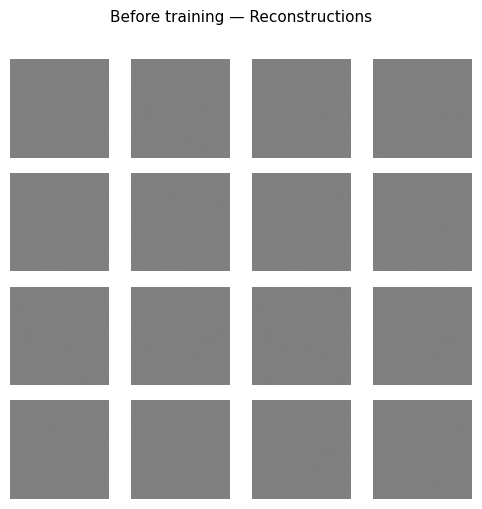

In [ ]:
# Fix a test sample that we will use for every epoch
assert BATCH_SIZE >= NUM_EXAMPLES_TO_GENERATE
for test_batch in test_dataset.take(1):
    test_sample = test_batch[0:NUM_EXAMPLES_TO_GENERATE, :, :, :]

print(f"Test sample shape: {test_sample.shape}")
print("Images before training (random output expected):")
generate_and_save_images(model, 0, test_sample)


Epoch 10/10  |  Test ELBO:  -156.25  |  Time: 14.8s


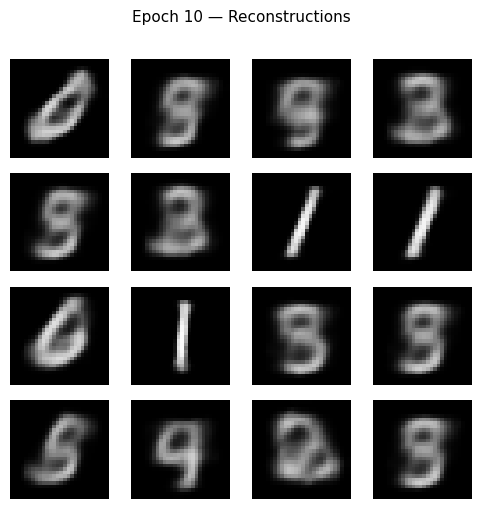


✅ Training complete!


In [ ]:
print("Starting training...\n")
elbo_history = []

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()

    # Training phase
    for train_x in train_dataset:
        train_step(model, train_x, optimizer)

    # Evaluation: test ELBO
    test_loss = tf.keras.metrics.Mean()
    for test_x in test_dataset:
        test_loss(compute_loss(model, test_x))

    elbo     = -test_loss.result().numpy()
    elapsed  = time.time() - start_time
    elbo_history.append(elbo)

    display.clear_output(wait=False)
    print(f"Epoch {epoch:02d}/{EPOCHS}  |  Test ELBO: {elbo:8.2f}  |  Time: {elapsed:.1f}s")

    generate_and_save_images(model, epoch, test_sample)

print("\n✅ Training complete!")


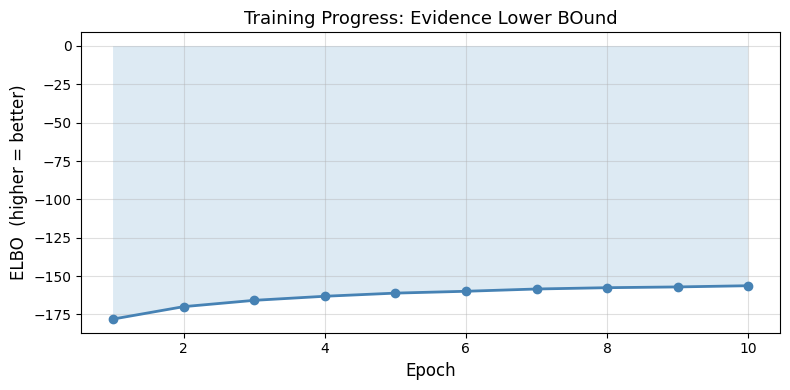

ELBO: -177.99 (epoch 1) → -156.25 (epoch 10)
Total improvement: +21.74 ELBO units


In [ ]:
# Plot the ELBO learning curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(elbo_history) + 1), elbo_history,
         marker='o', linewidth=2, color='steelblue')
plt.fill_between(range(1, len(elbo_history) + 1), elbo_history, alpha=0.15)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('ELBO  (higher = better)', fontsize=12)
plt.title('Training Progress: Evidence Lower BOund', fontsize=13)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f"ELBO: {elbo_history[0]:.2f} (epoch 1) → {elbo_history[-1]:.2f} (epoch {EPOCHS})")
print(f"Total improvement: +{elbo_history[-1] - elbo_history[0]:.2f} ELBO units")


---
## 🎨 Step 8: Visualisations

### 8.1 Final Reconstructions


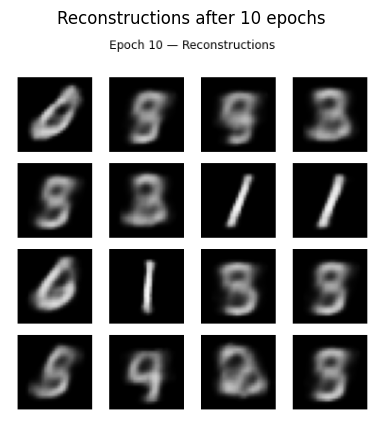

In [ ]:
plt.figure(figsize=(5, 5))
plt.imshow(PIL.Image.open(f'image_at_epoch_{EPOCHS:04d}.png'))
plt.axis('off')
plt.title(f"Reconstructions after {EPOCHS} epochs", fontsize=12)
plt.show()


### 8.2 Animated GIF — Training Progress

Watch how reconstructions improve epoch by epoch.


GIF saved: cvae_training.gif  (11 frames)


/tmp/ipykernel_1836/3786640545.py:6: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  writer.append_data(imageio.imread(filename))
/tmp/ipykernel_1836/3786640545.py:9: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  writer.append_data(imageio.imread(filenames[-1]))



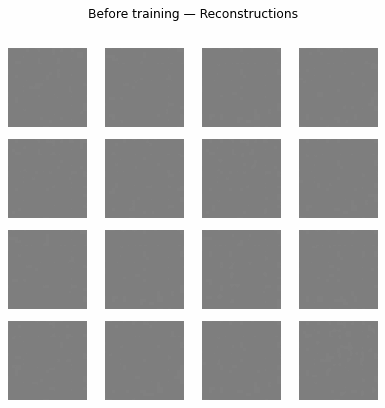

In [ ]:
anim_file = 'cvae_training.gif'

with imageio.get_writer(anim_file, mode='I', duration=0.7) as writer:
    filenames = sorted(glob.glob('image_at_epoch_*.png'))
    for filename in filenames:
        writer.append_data(imageio.imread(filename))
    # Hold final frame
    for _ in range(3):
        writer.append_data(imageio.imread(filenames[-1]))

print(f"GIF saved: {anim_file}  ({len(filenames)} frames)")

import tensorflow_docs.vis.embed as embed
embed.embed_file(anim_file)


### 8.3 2D Latent Space Manifold

We decode a **grid of z values** sampled using quantiles of $\mathcal{N}(0,1)$.

Using quantiles (rather than a uniform grid in Euclidean space) means we sample  
proportionally to the probability mass of the prior — giving a more meaningful view of the learned manifold.

The result should show **smooth morphing** between digit shapes — evidence that the VAE has learned a semantically organised latent space.


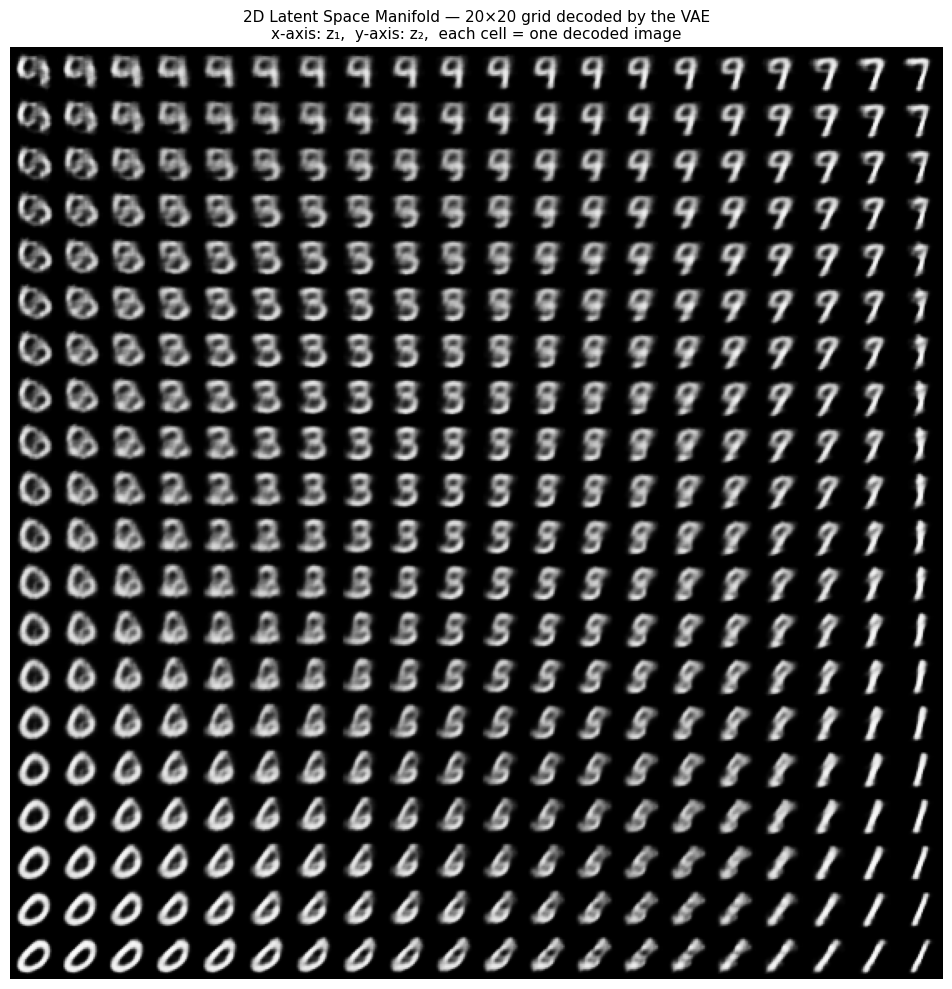

In [ ]:
def plot_latent_images(model, n=20, digit_size=28, figsize=10):
    """Decode an n×n grid of latent vectors and display as a large image.

    Uses Normal quantiles for grid coordinates instead of uniform spacing.
    This samples proportionally to the prior p(z) = N(0,1), giving a
    more representative view of the latent manifold.

    Args:
        model      : Trained CVAE
        n          : Grid is n×n
        digit_size : Each decoded image is digit_size × digit_size pixels
        figsize    : Output figure size in inches
    """
    norm = tfp.distributions.Normal(0, 1)
    grid_x = norm.quantile(np.linspace(0.05, 0.95, n)).numpy()
    grid_y = norm.quantile(np.linspace(0.05, 0.95, n)).numpy()

    canvas = np.zeros((digit_size * n, digit_size * n))

    for i, yi in enumerate(grid_x):
        for j, xi in enumerate(grid_y):
            z = np.array([[xi, yi]])              # (1, 2)
            x_decoded = model.sample(z)           # (1, 28, 28, 1)
            digit = tf.reshape(x_decoded[0], (digit_size, digit_size)).numpy()
            canvas[i*digit_size:(i+1)*digit_size,
                   j*digit_size:(j+1)*digit_size] = digit

    plt.figure(figsize=(figsize, figsize))
    plt.imshow(canvas, cmap='Greys_r')
    plt.title(
        f'2D Latent Space Manifold — {n}×{n} grid decoded by the VAE\n'
        f'x-axis: z₁,  y-axis: z₂,  each cell = one decoded image',
        fontsize=11)
    plt.xlabel('z₁  (1st latent dimension)', fontsize=10)
    plt.ylabel('z₂  (2nd latent dimension)', fontsize=10)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_latent_images(model, n=20)


### 8.4 Test-Set Encodings Coloured by Digit Class

We encode all 10,000 test images and plot their **mean vectors** $\mu$ in latent space,  
coloured by true label.

This reveals whether the VAE has discovered **semantic structure** — without ever seeing labels during training!


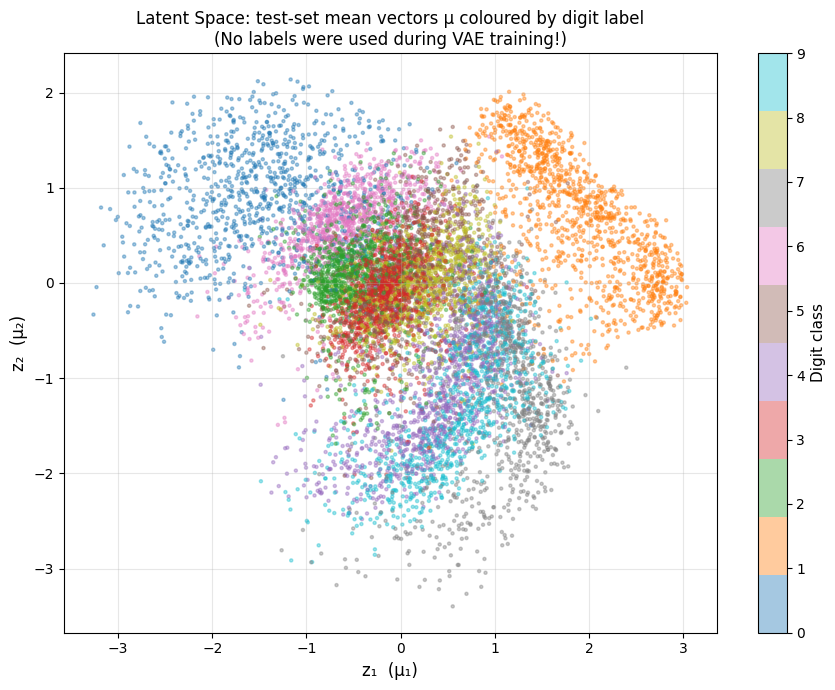

Notice: Digits with similar shapes (e.g. 4/9, 3/5/8) cluster nearby,
showing the VAE has learned a semantically meaningful latent space.


In [ ]:
all_means, all_labels = [], []

test_ds_labelled = (
    tf.data.Dataset.from_tensor_slices((test_images, test_labels)).batch(256)
)

for batch_imgs, batch_lbls in test_ds_labelled:
    mean, _ = model.encode(batch_imgs)
    all_means.append(mean.numpy())
    all_labels.append(batch_lbls.numpy())

all_means  = np.concatenate(all_means,  axis=0)   # (10000, 2)
all_labels = np.concatenate(all_labels, axis=0)   # (10000,)

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(all_means[:, 0], all_means[:, 1],
                c=all_labels, cmap='tab10', alpha=0.4, s=5)
cbar = plt.colorbar(sc, ax=ax, ticks=range(10))
cbar.set_label('Digit class', fontsize=11)
cbar.set_ticklabels(range(10))
ax.set_xlabel('z₁  (μ₁)', fontsize=12)
ax.set_ylabel('z₂  (μ₂)', fontsize=12)
ax.set_title(
    'Latent Space: test-set mean vectors μ coloured by digit label\n'
    '(No labels were used during VAE training!)', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Notice: Digits with similar shapes (e.g. 4/9, 3/5/8) cluster nearby,")
print("showing the VAE has learned a semantically meaningful latent space.")


### 8.5 Pure Generation: Sample from the Prior

Here we generate images by sampling $z \sim \mathcal{N}(0, I)$ — **no input images**.  
This is the VAE in pure generative mode.


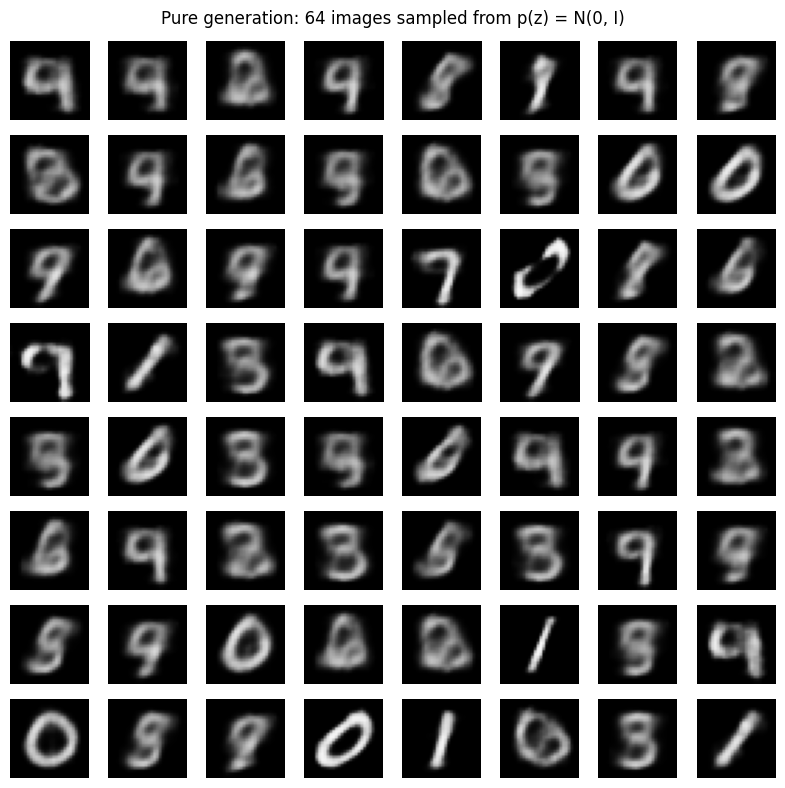

In [ ]:
tf.random.set_seed(123)
n_gen   = 64
z_samp  = tf.random.normal(shape=(n_gen, LATENT_DIM))
generated = model.sample(z_samp)   # (64, 28, 28, 1)

fig, axes = plt.subplots(8, 8, figsize=(8, 8))
fig.suptitle('Pure generation: 64 images sampled from p(z) = N(0, I)', fontsize=12)
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i, :, :, 0].numpy(), cmap='gray', vmin=0, vmax=1)
    ax.axis('off')
plt.tight_layout()
plt.show()


### 8.6 Latent Space Interpolation

We **interpolate** between two encoded test images in latent space.  
A smooth visual transition confirms that the latent space is continuous and well-structured.


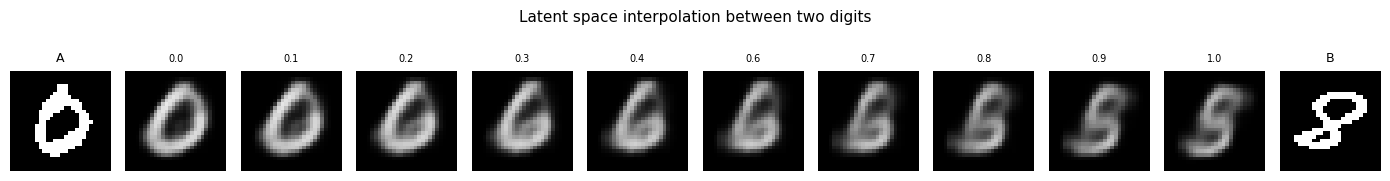

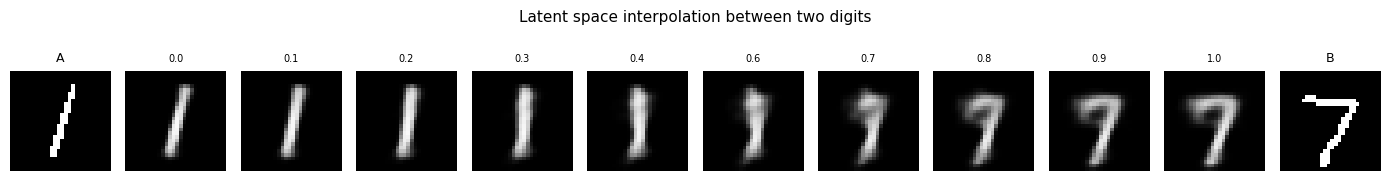

In [ ]:
def interpolate_latent(model, img_a, img_b, steps=10):
    """Linearly interpolate between two images in latent space.

    1. Encode both images → z_a, z_b
    2. Compute α-weighted combination: z = (1-α)·z_a + α·z_b
    3. Decode each z → image
    4. Display source → interpolated frames → target

    A smooth visual transition = well-structured latent space.
    """
    mean_a, logvar_a = model.encode(img_a[None])
    mean_b, logvar_b = model.encode(img_b[None])
    z_a = model.reparameterize(mean_a, logvar_a)
    z_b = model.reparameterize(mean_b, logvar_b)

    alphas   = np.linspace(0, 1, steps)
    z_interp = tf.constant(
        np.array([(1-a)*z_a.numpy() + a*z_b.numpy() for a in alphas])[:, 0, :],
        dtype=tf.float32)
    decoded = model.sample(z_interp)   # (steps, 28, 28, 1)

    fig, axes = plt.subplots(1, steps + 2, figsize=(14, 2))
    fig.suptitle('Latent space interpolation between two digits', fontsize=11)

    axes[0].imshow(img_a[:, :, 0], cmap='gray')
    axes[0].set_title('A', fontsize=9); axes[0].axis('off')

    for k in range(steps):
        axes[k+1].imshow(decoded[k, :, :, 0].numpy(), cmap='gray', vmin=0, vmax=1)
        axes[k+1].set_title(f'{alphas[k]:.1f}', fontsize=7)
        axes[k+1].axis('off')

    axes[-1].imshow(img_b[:, :, 0], cmap='gray')
    axes[-1].set_title('B', fontsize=9); axes[-1].axis('off')

    plt.tight_layout()
    plt.show()


idx_0 = np.where(test_labels == 0)[0][0]
idx_8 = np.where(test_labels == 8)[0][0]
interpolate_latent(model, test_images[idx_0], test_images[idx_8], steps=10)

# Try another pair
idx_1 = np.where(test_labels == 1)[0][0]
idx_7 = np.where(test_labels == 7)[0][0]
interpolate_latent(model, test_images[idx_1], test_images[idx_7], steps=10)


---
## 📝 Exercises

Work through these exercises in order of difficulty. Each builds on concepts from the demo.

---

### 🟢 Exercise 1 — Effect of Latent Dimension *(Easy)*

**Task:** Retrain the CVAE with a higher latent dimension (e.g., `latent_dim = 8` or `16`).

Answer the following questions:
1. Does the **test ELBO** improve with more latent dimensions? Explain why.
2. Does the **reconstruction quality** visually improve?
3. What do you **lose** compared to `latent_dim = 2`?

*Hint: You can no longer use `plot_latent_images` (which assumes 2D). What alternative visualisations exist for higher-dimensional latent spaces (think dimensionality reduction)?*


In [ ]:
# ── Exercise 1: Your code here ───────────────────────────────────────────────
LATENT_DIM_EX1 = 16      # Try 4, 8, 16, 32 — compare the results
EPOCHS_EX1     = 10

model_ex1     = CVAE(LATENT_DIM_EX1)
optimizer_ex1 = tf.keras.optimizers.Adam(learning_rate=1e-4)

elbo_ex1 = []
for epoch in range(1, EPOCHS_EX1 + 1):
    for train_x in train_dataset:
        train_step(model_ex1, train_x, optimizer_ex1)
    test_loss = tf.keras.metrics.Mean()
    for test_x in test_dataset:
        test_loss(compute_loss(model_ex1, test_x))
    elbo_ex1.append(-test_loss.result().numpy())
    print(f"Epoch {epoch}/{EPOCHS_EX1}  ELBO: {elbo_ex1[-1]:.2f}")

# Compare learning curves
plt.figure(figsize=(8, 4))
plt.plot(elbo_history, label=f'latent_dim={LATENT_DIM}', marker='o')
plt.plot(elbo_ex1, label=f'latent_dim={LATENT_DIM_EX1}', marker='s')
plt.xlabel('Epoch'); plt.ylabel('ELBO')
plt.title('ELBO: effect of latent dimension')
plt.legend(); plt.grid(True, alpha=0.4); plt.show()

# TODO: Add your written observations here
# Q1 — ELBO improvement?
# Q2 — Visual quality?
# Q3 — What is lost?


---

### 🟡 Exercise 2 — Deeper Encoder *(Medium)*

The current encoder uses two convolutional layers (32 and 64 filters).

**Task:** Add a **third convolutional layer** (`Conv2D(128, kernel_size=3, strides=2)`) to the encoder,  
and add a **matching `Conv2DTranspose`** layer to the decoder.

1. How does this change the **number of trainable parameters**?
2. What are the **spatial dimensions** after three stride-2 convolutions on a 28×28 image?  
   *(Hint: 28 → 13 → 6 → ?)*
3. How must the decoder's first `Dense` layer size change to match?
4. Does the deeper architecture improve the **ELBO**? Does it help or hurt **per-epoch training speed**?

*Caution: MNIST is small — going too deep risks the spatial dimensions collapsing to 1×1 or 0×0.*


In [ ]:
# ── Exercise 2: Your code here ───────────────────────────────────────────────

class DeepCVAE(tf.keras.Model):
    """
    TODO: Build a 3-layer convolutional encoder/decoder.

    Encoder spatial progression:
      28×28 → 13×13 (stride=2) → 6×6 (stride=2) → ? (stride=2)

    Task: Fill in the missing pieces marked with TODO.
    """

    def __init__(self, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder = tf.keras.Sequential([
            tf.keras.layers.InputLayer(input_shape=(28, 28, 1)),
            tf.keras.layers.Conv2D(32,  3, strides=2, activation='relu'),
            tf.keras.layers.Conv2D(64,  3, strides=2, activation='relu'),
            # TODO: Add Conv2D(128, kernel_size=3, strides=2, activation='relu')
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(latent_dim + latent_dim),
        ])

        self.decoder = tf.keras.Sequential([
            tf.keras.layers.InputLayer(input_shape=(latent_dim,)),
            # TODO: What is the spatial size entering the decoder?
            #       Compute: output_size = floor((input - kernel + 2*padding) / stride) + 1
            #       Then set Dense(units = H * W * filters)
            tf.keras.layers.Dense(units=7 * 7 * 32, activation='relu'),  # <-- ADJUST
            tf.keras.layers.Reshape(target_shape=(7, 7, 32)),             # <-- ADJUST
            # TODO: Add a matching Conv2DTranspose layer here
            tf.keras.layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu'),
            tf.keras.layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu'),
            tf.keras.layers.Conv2DTranspose(1,  3, strides=1, padding='same'),
        ])

    def encode(self, x):
        mean, logvar = tf.split(self.encoder(x), num_or_size_splits=2, axis=1)
        return mean, logvar

    def reparameterize(self, mean, logvar):
        eps = tf.random.normal(shape=mean.shape)
        return eps * tf.exp(logvar * 0.5) + mean

    def decode(self, z, apply_sigmoid=False):
        logits = self.decoder(z)
        return tf.sigmoid(logits) if apply_sigmoid else logits

    @tf.function
    def sample(self, eps=None):
        if eps is None:
            eps = tf.random.normal(shape=(100, self.latent_dim))
        return self.decode(eps, apply_sigmoid=True)


# Uncomment after completing the TODO items above:
# model_deep = DeepCVAE(latent_dim=2)
# _ = model_deep.encode(tf.zeros([1, 28, 28, 1]))
# model_deep.encoder.summary()
# model_deep.decoder.summary()


---

### 🔴 Exercise 3 — Latent Arithmetic *(Hard)*

A well-trained VAE with a structured latent space supports **semantic arithmetic**.

**Task:** For a source digit A and a target digit B:
1. Encode many examples of A → compute the **centroid** $\bar{z}_A$ (mean of their $\mu$ vectors)
2. Encode many examples of B → compute the **centroid** $\bar{z}_B$
3. Compute the **direction vector**: $\Delta z = \bar{z}_B - \bar{z}_A$
4. Take new images of digit A, encode them, **add** $\Delta z$ to each latent vector
5. Decode the shifted vectors — do they look like digit B?

This is analogous to the famous **Word2Vec arithmetic**: *king − man + woman ≈ queen*.

**Bonus:** Test multiple digit pairs (e.g., 1→7, 3→8, 6→9). Which pairs work well and which do not? Why?


In [ ]:
# ── Exercise 3: Implement and test latent arithmetic ─────────────────────────

def class_mean_latent(model, images, labels, digit_class, n_samples=300):
    """
    Encode n_samples images of digit_class and return the mean of their μ vectors.
    This gives the 'centroid' of that digit class in latent space.

    Args:
        model       : Trained CVAE
        images      : Full image array (test_images)
        labels      : Corresponding labels (test_labels)
        digit_class : Which digit (0–9)
        n_samples   : How many examples to encode
    Returns:
        mean_z: numpy array of shape (latent_dim,) — the centroid
    """
    # TODO:
    # 1. Filter images/labels to get only digit_class examples
    # 2. Sample n_samples of them (or use all if fewer exist)
    # 3. Encode them → get μ vectors
    # 4. Return the mean of μ across samples
    idx = np.where(labels == digit_class)[0][:n_samples]
    imgs = tf.constant(images[idx], dtype=tf.float32)
    means, _ = model.encode(imgs)
    return tf.reduce_mean(means, axis=0).numpy()   # shape (latent_dim,)


def latent_arithmetic(model, images, labels, source, target, n_test=8):
    """
    Perform latent arithmetic: encode source digits → shift by Δz → decode.

    Δz = centroid(target) − centroid(source)

    Display: [original source] | [shifted → decoded]
    """
    # TODO:
    # 1. Compute centroids
    # 2. Compute delta_z
    # 3. Pick n_test test images of source digit
    # 4. Encode → z_source
    # 5. z_new = z_source + delta_z
    # 6. Decode z_new with sigmoid
    # 7. Display before/after pairs

    centroid_source = class_mean_latent(model, images, labels, source)
    centroid_target = class_mean_latent(model, images, labels, target)
    delta_z = centroid_target - centroid_source

    # Get n_test examples of source digit
    idx = np.where(labels == source)[0][:n_test]
    src_imgs = tf.constant(images[idx], dtype=tf.float32)

    # Encode
    mean, logvar = model.encode(src_imgs)
    z_src = model.reparameterize(mean, logvar)

    # Shift
    z_new = z_src + delta_z[None, :]   # broadcast delta_z over batch

    # Decode both original and shifted
    recon_orig = model.sample(z_src)
    recon_new  = model.sample(z_new)

    # Display
    fig, axes = plt.subplots(2, n_test, figsize=(12, 3))
    fig.suptitle(
        f'Latent arithmetic: {source} → {target}\n'
        f'Top = reconstructed {source},  Bottom = after adding Δz (should look like {target})',
        fontsize=11)
    for i in range(n_test):
        axes[0, i].imshow(recon_orig[i, :, :, 0].numpy(), cmap='gray', vmin=0, vmax=1)
        axes[0, i].axis('off')
        axes[1, i].imshow(recon_new[i,  :, :, 0].numpy(), cmap='gray', vmin=0, vmax=1)
        axes[1, i].axis('off')
    plt.tight_layout()
    plt.show()


# Test with a few digit pairs
latent_arithmetic(model, test_images, test_labels, source=3, target=8)
latent_arithmetic(model, test_images, test_labels, source=1, target=7)

# TODO: Try more pairs and discuss:
# - Which transformations work well?
# - Which fail? Why might that be?
# - How does latent_dim affect the quality of arithmetic?


---
## 🏁 Summary & Key Takeaways

| Concept | What we learned |
|---|---|
| **VAE vs AE** | VAE encodes to a *distribution* ($\mu$, $\sigma$), not a point → continuous, generative latent space |
| **ELBO loss** | Training maximises: Reconstruction − KL divergence. KL term regularises the latent space toward $\mathcal{N}(0, I)$ |
| **Reparameterization** | $z = \mu + \sigma \odot \epsilon$ makes sampling differentiable; gradients flow through $\mu$ and $\sigma$ |
| **Log-variance** | Parameterising $\log \sigma^2$ (not $\sigma^2$) gives an unconstrained, numerically stable output |
| **Latent structure** | 2D latent space self-organises into semantic clusters — *without* label supervision |
| **Generation** | Sample $z \sim \mathcal{N}(0, I)$, decode → new image. The prior is the generator's input |
| **Interpolation & Arithmetic** | Smooth paths and direction vectors in latent space have semantic meaning |

---

### 📖 Further Reading

- **Original VAE paper:** Kingma & Welling (2013) — [Auto-Encoding Variational Bayes](https://arxiv.org/abs/1312.6114)
- **Rezende et al. (2014):** [Stochastic Backpropagation and Approximate Inference in Deep Generative Models](https://arxiv.org/abs/1401.4082)
- **β-VAE** (disentangled representations): [Higgins et al. (2017)](https://openreview.net/forum?id=Sy2fchgwl)
- **VQ-VAE** (discrete latent space): [van den Oord et al. (2017)](https://arxiv.org/abs/1711.00937)
- **TF official tutorial:** https://www.tensorflow.org/tutorials/generative/cvae
